In [1]:
#this is a generic code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. Replace all of the "placeholders" with the files/parameters that you are looking for.

In [ ]:
pip install hampel
pip install scipy
pip install pandas

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from hampel import hampel #this allows the hampel package to run

In [5]:
#the code chunk above installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [6]:
import os #allows python to communicate directly with the computer's operating system

In [16]:
#reading the continuous data
hobodf = pd.read_csv("P1_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv is a placeholder for the name of your csv with all the continuous hobo data
hobodf = hobodf.dropna()
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"])#Date-Time (CST/CDT) is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
hobodf["Temp"] = pd.to_numeric(hobodf["Temp"])
date = hobodf["Date-Time"] #this names the variable "date"
sliceddate = date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.

In [19]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
hampelhobo = hampel(hobodf["Temp"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. Temperature (W-CT 22414702), °C is a placeholder for the name of the column with the parameter of interest. filteredhobo is a placeholder.
filteredhoboseries = pd.Series(hampelhobo.filtered_data, index = hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
filteredhobo = filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 

In [9]:
#reading the manual data
mandf = pd.read_csv("Well_Sampling_Data_P1.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
mandf.loc[:,"Temp bottom before"] #selects the column in the manual data csv that you want on the y-axis. Temp bottom before is a placeholder for whichever column you'd like to see.
mandf["Date"] = pd.to_datetime(mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

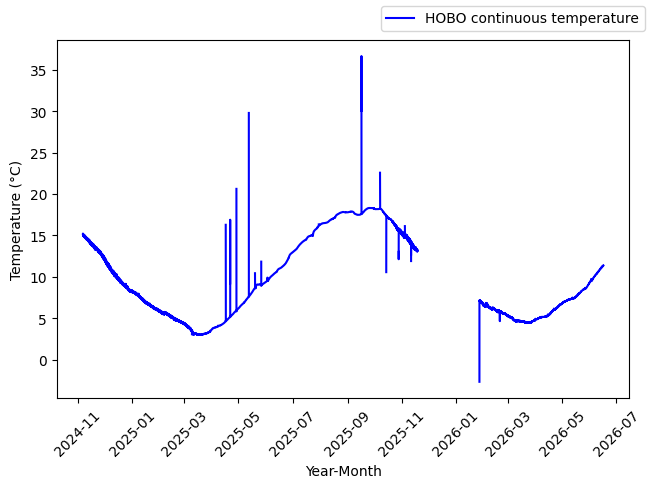

In [20]:
#creating the plot
mandf.columns = mandf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
ax.plot(sliceddate, filteredhobo, color="blue", label = "HOBO continuous temperature")
# ax.plot(mandf.Date, mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
# ax.plot(mandf.Date, mandf.loc[:,"Temp bottom before"], 'x', color = "purple", label = "manual temperature at bottom before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
# ax.plot(mandf.Date, mandf.loc[:,"Temp bottom after"], 'o', color = "purple", label = "manual temperature at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.

fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

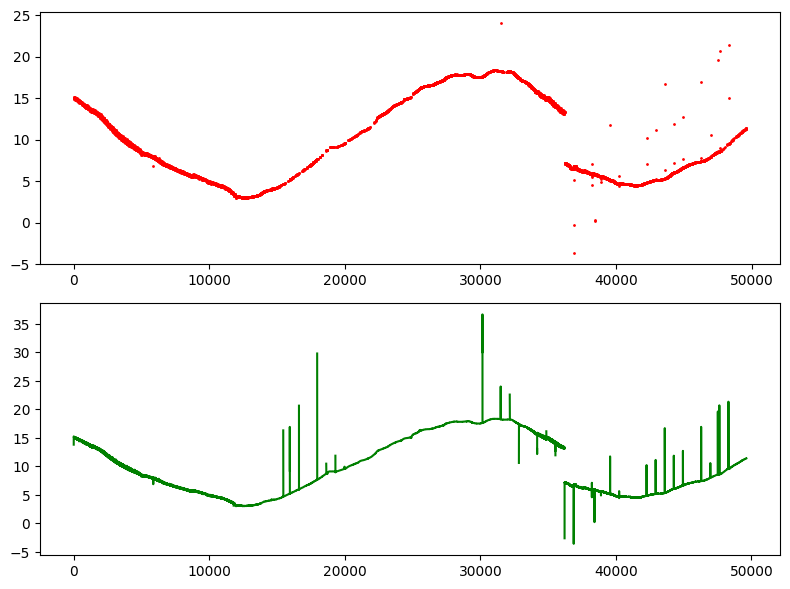

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
for i in hampelhobo.outlier_indices:
    axes[0].plot(i, hobodf["Temp"][i], 'ro', markersize=1)  # Mark as red


# Plot the filtered data in the second subplot
axes[1].plot(hobodf["Temp"], label='Filtered Data', color='g')


# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

In [12]:
display(filteredhobo.to_string())

'1        15.170000\n2        15.230000\n3        15.190000\n4        15.130000\n5        15.190000\n6        15.160000\n7        15.160000\n8        15.160000\n9        15.170000\n10       15.170000\n11       15.130000\n12       15.010000\n13       15.100000\n14       14.990000\n15       14.980000\n16       15.050000\n17       15.150000\n18       15.150000\n19       15.020000\n20       15.130000\n21       15.020000\n22       15.010000\n23       14.970000\n24       15.030000\n25       14.950000\n26       14.980000\n27       15.110000\n28       14.980000\n29       15.060000\n30       15.100000\n31       15.010000\n32       15.090000\n33       15.060000\n34       14.960000\n35       14.980000\n36       15.110000\n37       15.060000\n38       15.040000\n39       15.030000\n40       15.060000\n41       15.040000\n42       15.020000\n43       15.040000\n44       15.060000\n45       14.980000\n46       15.070000\n47       15.010000\n48       15.100000\n49       14.960000\n50       15.080000\